In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import snowflake.connector

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

USER=os.getenv("user")
PASSWORD=os.getenv("password")
ACCOUNT=os.getenv("account")
WAREHOUSE=os.getenv("warehouse")         
DATABASE=os.getenv('database')
SCHEMA=os.getenv('schema')

In [3]:
# conn = snowflake.connector.connect(
#     user=user,
#     password=password,
#     account=account,  
#     warehouse=warehouse,             
#     database=database,
#     schema=schema
# )

In [4]:
# conn.close()

In [5]:
def run_query(query):
    with snowflake.connector.connect(
        user=USER,
        password=PASSWORD,
        account=ACCOUNT,
        warehouse=WAREHOUSE,
        database=DATABASE,
        schema=SCHEMA
    ) as conn:
        with conn.cursor() as cursor:
            cursor.execute(query)
            return cursor.fetch_pandas_all()

In [6]:
# try:
#     cursor = conn.cursor()

#     cursor.execute("select * from taxi_trips")

#     df = cursor.fetch_pandas_all()

#     print(df.head())

# finally:
#     cursor.close()
#     conn.close()

In [7]:
head_query = """
select * from taxi_trips
limit 10
"""

head_df = run_query(head_query)

In [8]:
head_df.head()

,VENDORID,TPEP_PICKUP_DATETIME,TPEP_DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODEID,STORE_AND_FWD_FLAG,PULOCATIONID,DOLOCATIONID,PAYMENT_TYPE,FARE_AMOUNT,EXTRA,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,CONGESTION_SURCHARGE,AIRPORT_FEE,ABS_FARE,ABS_TOTAL,PICKUP_MONTH,PICKUP_DAY,PICKUP_HOUR,PICKUP_DAY_OF_WEEK_NUM,PICKUP_DAY_OF_WEEK,PICKUP_DATE,IS_WEEKEND,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
0,2,1672598988000000,1672599895000000,1.000,2.890,1.000,N,137,236,1,17.000,0.000,0.500,5.250,0.000,1.000,26.250,2.500,0.000,17.000,26.250,1,1,18,6,Sunday,2023-01-01,True,15.117,2023-01-01 18:49:48,2023-01-01 19:04:55
1,2,1672598445000000,1672599382000000,1.000,9.600,1.000,N,233,138,1,37.300,5.000,0.500,5.000,6.550,1.000,57.850,2.500,0.000,37.300,57.850,1,1,18,6,Sunday,2023-01-01,True,15.617,2023-01-01 18:40:45,2023-01-01 18:56:22
2,1,1672596037000000,1672596735000000,1.000,1.800,1.000,N,236,151,1,12.800,2.500,0.500,2.750,0.000,1.000,19.550,2.500,0.000,12.800,19.550,1,1,18,6,Sunday,2023-01-01,True,11.633,2023-01-01 18:00:37,2023-01-01 18:12:15
3,2,1672597205000000,1672599885000000,1.000,18.840,2.000,N,132,231,1,70.000,0.000,0.500,15.050,0.000,1.000,90.300,2.500,1.250,70.000,90.300,1,1,18,6,Sunday,2023-01-01,True,44.667,2023-01-01 18:20:05,2023-01-01 19:04:45
4,2,1672597446000000,1672599178000000,1.000,4.280,1.000,N,230,148,1,28.900,0.000,0.500,6.580,0.000,1.000,39.480,2.500,0.000,28.900,39.480,1,1,18,6,Sunday,2023-01-01,True,28.867,2023-01-01 18:24:06,2023-01-01 18:52:58


In [9]:
location_key = pd.read_csv('../taxi_zone_lookup.csv')

In [10]:
location_key

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [11]:
# TODO: Make new view in snowflake to have the location data

# df = df\
#     .merge(location_key, how='left', left_on='PULOCATIONID', right_on='LocationID')\
#     .rename(columns={'Borough': 'PUBOROUGH', 'Zone': 'PUZONE', 'service_zone': 'PUSERVICEZONE'})\
#     .drop(columns='LocationID')\
#     .merge(location_key, how='left', left_on='DOLOCATIONID', right_on='LocationID')\
#     .rename(columns={'Borough': 'DOBOROUGH', 'Zone': 'DOZONE', 'service_zone': 'DOSERVICEZONE'})\
#     .drop(columns='LocationID')

## Understanding the Dataset

> There are 35.7M rows in this dataset spaning across all 12 months in 2023.
>
> We have 31 columns of data to work with, most are from the original dataset, but others, such as pickup date, month, hour, and trip duration were created in the data cleaning/transformation steps

In [12]:
head_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   VENDORID                10 non-null     int8          
 1   TPEP_PICKUP_DATETIME    10 non-null     int64         
 2   TPEP_DROPOFF_DATETIME   10 non-null     int64         
 3   PASSENGER_COUNT         10 non-null     float64       
 4   TRIP_DISTANCE           10 non-null     float64       
 5   RATECODEID              10 non-null     float64       
 6   STORE_AND_FWD_FLAG      10 non-null     object        
 7   PULOCATIONID            10 non-null     int16         
 8   DOLOCATIONID            10 non-null     int16         
 9   PAYMENT_TYPE            10 non-null     int8          
 10  FARE_AMOUNT             10 non-null     float64       
 11  EXTRA                   10 non-null     float64       
 12  MTA_TAX                 10 non-null     float64      

In [13]:
# df.describe()

In [14]:
summary_query = \
"""
select 
    avg(fare_amount) as avg_fare,
    median(fare_amount) as median_fare,
    avg(total_amount) as avg_total,
    median(total_amount) as median_total,
    avg(trip_distance) as avg_trip_distance,
    median(trip_distance) as median_trip_distance,
    avg(passenger_count) as avg_passenger_count,
    median(passenger_count) as median_passenger_count,
    avg(trip_duration_minutes) as avg_trip_duration,
    median(trip_duration_minutes) as median_trip_duration
from taxi_trips;
"""

run_query(summary_query)

,AVG_FARE,MEDIAN_FARE,AVG_TOTAL,MEDIAN_TOTAL,AVG_TRIP_DISTANCE,MEDIAN_TRIP_DISTANCE,AVG_PASSENGER_COUNT,MEDIAN_PASSENGER_COUNT,AVG_TRIP_DURATION,MEDIAN_TRIP_DURATION
0,19.863,13.500,29.056,21.000,3.472,1.800,1.393,1.000,17.519,12.617


### Summary Statistics

| Column | Average | Median | Insights | 
| ------ | ------- | ------ | -------- |
| Fare Amount | \$19.86 | \$13.50 | As the mean is higher than the median, there is a slight rightward skew in the data. We will confirm this with visualiations later. |
| Total Amount | \$29.06 | \$21.00 | Same as Fare Amount, there may be a slight right skew |
| Trip Distance (Miles) | 3.47 | 1.8 | During cleaning process, we did remove trips greater than 100 miles, as these are abnormalities. |
| Passenger Count | 1.39 | 1 | Most trips only had one passenger |
| Trip Duration (minutes) | 17.52 | 12.62 | This is also right skewed slightly as the mean is higher than the median | 


## Trip Behavior

In [15]:
duration_query = \
"""
select trip_duration_minutes
from taxi_trips;
"""

duration_df = run_query(duration_query)

In [16]:
duration_df.describe()

,TRIP_DURATION_MINUTES
count,35710902.000
mean,17.519
std,42.267
min,0.000
25%,7.650
50%,12.617
75%,20.617
max,10029.183


<Axes: xlabel='TRIP_DURATION_MINUTES', ylabel='Count'>

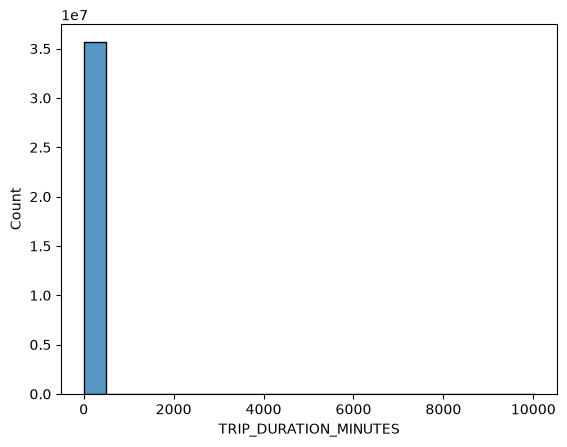

In [17]:
sns.histplot(data=duration_df, x='TRIP_DURATION_MINUTES', bins=20)

We can see in the above histogram and summary statistics that there are major outliers causing the plot to become inaccurate

In [18]:
# sns.histplot(x=np.log(df['TRIP_DURATION_MINUTES']), bins=20)

Let's look at the 20 longest trips to see if we can uncover outliers missed during the original cleaning

In [19]:
duration_largest_query = \
"""
select 
    TRIP_DURATION_MINUTES,
    PICKUP_DATETIME,
    DROPOFF_DATETIME,
    TRIP_DISTANCE,
    FARE_AMOUNT,
    TOTAL_AMOUNT
from taxi_trips
order by TRIP_DURATION_MINUTES desc
limit 20;
"""

df_20_largest = run_query(duration_largest_query)

In [20]:
df_20_largest

,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME,TRIP_DISTANCE,FARE_AMOUNT,TOTAL_AMOUNT
0,10029.183,2023-01-23 11:21:51,2023-01-30 10:31:02,0.000,3.000,4.500
1,9987.117,2023-05-24 12:51:56,2023-05-31 11:19:03,0.000,3.000,4.500
2,9137.083,2023-08-16 08:19:21,2023-08-22 16:36:26,0.000,3.000,4.500
3,9014.900,2023-08-02 11:05:52,2023-08-08 17:20:46,0.000,3.700,5.200
4,7352.117,2023-08-31 08:33:05,2023-09-05 11:05:12,0.000,3.000,4.500
5,7348.833,2023-07-14 12:52:23,2023-07-19 15:21:13,0.000,3.000,4.500
6,7266.850,2023-08-16 10:56:52,2023-08-21 12:03:43,0.000,3.000,4.500
7,7188.317,2023-12-15 11:42:05,2023-12-20 11:30:24,0.000,4.400,5.900
8,7053.617,2023-02-23 14:59:05,2023-02-28 12:32:42,14.340,80.000,82.750
9,6764.150,2023-08-28 18:13:03,2023-09-02 10:57:12,0.670,14.200,20.700


In [21]:
duration_df["TRIP_DURATION_MINUTES"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35710902.000
mean          17.519
std           42.267
min            0.000
50%           12.617
75%           20.617
90%           32.583
95%           43.283
99%           67.967
99.9%        159.202
max        10029.183
Name: TRIP_DURATION_MINUTES, dtype: float64

In [22]:
p99 = duration_df["TRIP_DURATION_MINUTES"].quantile(.99)

duration_df_filtered = duration_df[
    duration_df["TRIP_DURATION_MINUTES"] <= p99
]

<Axes: xlabel='TRIP_DURATION_MINUTES', ylabel='Count'>

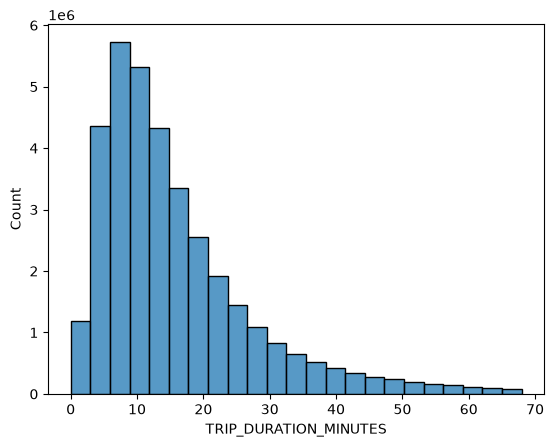

In [23]:
sns.histplot(data=duration_df_filtered, x='TRIP_DURATION_MINUTES', binwidth=3)

In [24]:
duration_df[
    (duration_df["TRIP_DURATION_MINUTES"] > 240)
].shape

(33065, 1)

In [25]:
duration_df[
    (duration_df["TRIP_DURATION_MINUTES"] > 240)
]["TRIP_DURATION_MINUTES"].describe()

count   33065.000
mean     1277.951
std       385.119
min       240.133
25%      1384.617
50%      1419.833
75%      1433.033
max     10029.183
Name: TRIP_DURATION_MINUTES, dtype: float64

In [26]:
duration_df_filtered["TRIP_DURATION_MINUTES"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35353941.000
mean          15.751
std           11.683
min            0.000
50%           12.500
75%           20.267
90%           31.350
95%           40.517
99%           57.683
99.9%         66.567
max           67.967
Name: TRIP_DURATION_MINUTES, dtype: float64

> There are around 33,065 rows that have trip durations over 4 hours. Looking at the 20 longest trips, many of them went on for days, but had a distance of 0 and very low fares. These are likely data entry errors and so were excluded from the visualization and analysis by limiting it to the 99th percentile ,which is just over an hour. 

### Key Findings

- Median trip duration was 12.5 minutes.
- 95% of trips were shorter than 40.5 minutes.
- Several duration outliers spanning multiple days were identified.
- These outliers were associated with zero-distance, minimum-fare trips, and durations spanning multiple days
- A histogram of the rows up to the 99th percentile for duration was generated, and was found to be right skewed
- The majority of trips were between 5 and 20 minutes.
- Further investigation required before establishing a duration cleaning rule

## Fare Amounts

In [27]:
fare_query = \
"""
select 
    fare_amount,
    total_amount,
    trip_distance,
    trip_duration_minutes,
    pickup_datetime,
    dropoff_datetime
from taxi_trips
"""

fare_df = run_query(fare_query)

In [28]:
total_amount_df = fare_df.copy(deep=True)

In [29]:
fare_df.describe()

,FARE_AMOUNT,TOTAL_AMOUNT,TRIP_DISTANCE,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
count,35710902.000,35710902.000,35710902.000,35710902.000,35710902,35710902
mean,19.863,29.056,3.472,17.519,2023-07-01 22:51:06.060989,2023-07-01 23:08:37.214274
min,0.000,0.000,0.000,0.000,2023-01-01 00:00:05,2023-01-01 00:03:28
25%,9.300,15.960,1.060,7.650,2023-04-01 20:10:56,2023-04-01 20:26:42
50%,13.500,21.000,1.800,12.617,2023-06-26 10:39:25.500000,2023-06-26 10:56:59
75%,21.900,30.800,3.400,20.617,2023-10-05 21:17:18,2023-10-05 21:33:15
max,386983.630,386987.630,99.920,10029.183,2023-12-31 23:59:59,2024-01-02 20:13:25
std,78.104,79.420,4.556,42.267,NaN,NaN


we can see in the above description, the largest fare is $386,983. This doesn't make a lot of sense, so let's look at the rows with the largest fares.

the median fare was \\$13.5 and the average was \$19.86

In [30]:
fare_df.nlargest(20, 'FARE_AMOUNT')

,FARE_AMOUNT,TOTAL_AMOUNT,TRIP_DISTANCE,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
10173229,386983.630,386987.630,1.500,11.117,2023-06-12 13:33:06,2023-06-12 13:44:13
28874100,187502.960,187513.900,21.300,57.000,2023-09-02 15:15:39,2023-09-02 16:12:39
6503327,143163.450,143167.450,0.700,4.717,2023-09-05 10:16:13,2023-09-05 10:20:56
28998012,19152.900,29156.900,0.000,0.000,2023-09-11 14:54:55,2023-09-11 14:54:55
22074625,6300.900,6304.900,40.810,274.567,2023-05-16 10:12:28,2023-05-16 14:47:02
20133711,2449.500,2451.000,12.580,302.433,2023-04-06 14:08:51,2023-04-06 19:11:17
3588083,2320.110,2372.790,6.700,27.033,2023-12-20 18:49:49,2023-12-20 19:16:51
101860,2203.100,2208.100,0.000,0.000,2023-02-08 23:44:44,2023-02-08 23:44:44
12329161,2194.700,2203.140,44.510,3011.383,2023-12-17 13:28:53,2023-12-19 15:40:16
24261269,1116.700,1120.700,0.000,0.000,2023-08-24 14:25:40,2023-08-24 14:25:40


The trip with the largest fare was only 1.5 miles and lasted only 11 minutes. this would not warrent a fare of that amount. This is also true for the other rows as well having high fares. Let's look at percentiles of the fare amount. 

In [31]:
fare_df["FARE_AMOUNT"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35710902.000
mean          19.863
std           78.104
min            0.000
50%           13.500
75%           21.900
90%           42.500
95%           70.000
99%           77.900
99.9%        150.000
max       386983.630
Name: FARE_AMOUNT, dtype: float64

The 99th percentile of the fare amounts is only $77.9. Let's see how many rows there are that are above this amount. 

In [32]:
f99 = fare_df['FARE_AMOUNT'].quantile(.99)

In [33]:
high_fare_df = fare_df[fare_df['FARE_AMOUNT'] > f99]

In [34]:
high_fare_df.shape

(356816, 6)

There are 356.8K+ rows that have fare amounts above the 99th percentile. 

In [35]:
filtered_fare_df = fare_df[fare_df['FARE_AMOUNT'] <= f99]

<Axes: xlabel='FARE_AMOUNT', ylabel='Count'>

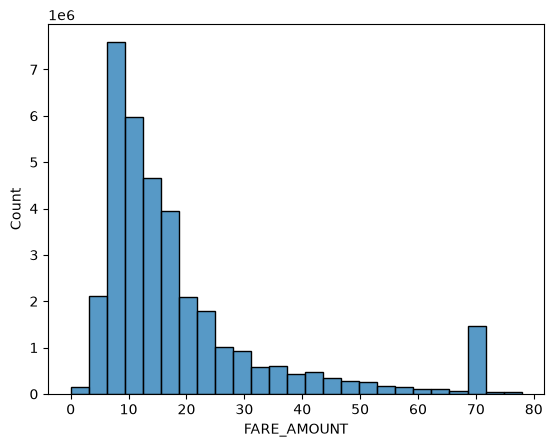

In [36]:
sns.histplot(data=filtered_fare_df, x='FARE_AMOUNT', bins=25)

From the above histogram of the filtered fare dataframe (containing only rows below the 99th percentile), we see that most of the fares are between 5 and 20 dollars. However, there is a spike in fare amounts that are around $70. 

### Key Findings
- The median fare amount is \$13.5
- The average fare amount is \$19.86
- The highest fare is over \$300,000
- The extreme fare values investigated did not appear to have a justifiable relationship to trip distance or duration.
- The 99th percentile is only ~\$77
- Majority of fares are between \$5 and \\$20, with a spike at around \\$70
- Further investigation required before establishing a fare amount cleaning rule

## Total Amount

In [38]:
total_amount_df.describe()

,FARE_AMOUNT,TOTAL_AMOUNT,TRIP_DISTANCE,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
count,35710902.000,35710902.000,35710902.000,35710902.000,35710902,35710902
mean,19.863,29.056,3.472,17.519,2023-07-01 22:51:06.060989,2023-07-01 23:08:37.214274
min,0.000,0.000,0.000,0.000,2023-01-01 00:00:05,2023-01-01 00:03:28
25%,9.300,15.960,1.060,7.650,2023-04-01 20:10:56,2023-04-01 20:26:42
50%,13.500,21.000,1.800,12.617,2023-06-26 10:39:25.500000,2023-06-26 10:56:59
75%,21.900,30.800,3.400,20.617,2023-10-05 21:17:18,2023-10-05 21:33:15
max,386983.630,386987.630,99.920,10029.183,2023-12-31 23:59:59,2024-01-02 20:13:25
std,78.104,79.420,4.556,42.267,NaN,NaN


we can see in the above description, the largest total amount is $386,987.63. Like with the fares, his doesn't make a lot of sense, so let's look at the rows with the largest total amounts.

the median total amount was \\$21 and the average was \$26.06

In [39]:
total_amount_df.nlargest(20, 'TOTAL_AMOUNT')

,FARE_AMOUNT,TOTAL_AMOUNT,TRIP_DISTANCE,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
10173229,386983.630,386987.630,1.500,11.117,2023-06-12 13:33:06,2023-06-12 13:44:13
28874100,187502.960,187513.900,21.300,57.000,2023-09-02 15:15:39,2023-09-02 16:12:39
6503327,143163.450,143167.450,0.700,4.717,2023-09-05 10:16:13,2023-09-05 10:20:56
28998012,19152.900,29156.900,0.000,0.000,2023-09-11 14:54:55,2023-09-11 14:54:55
22074625,6300.900,6304.900,40.810,274.567,2023-05-16 10:12:28,2023-05-16 14:47:02
20133711,2449.500,2451.000,12.580,302.433,2023-04-06 14:08:51,2023-04-06 19:11:17
3588083,2320.110,2372.790,6.700,27.033,2023-12-20 18:49:49,2023-12-20 19:16:51
101860,2203.100,2208.100,0.000,0.000,2023-02-08 23:44:44,2023-02-08 23:44:44
12329161,2194.700,2203.140,44.510,3011.383,2023-12-17 13:28:53,2023-12-19 15:40:16
24261269,1116.700,1120.700,0.000,0.000,2023-08-24 14:25:40,2023-08-24 14:25:40


Thr trip that had the largest fare also had the highest total amount. This is true for the other rows of high fares as well, where they also had the highest total amounts. One difference is row 9,150,745, which had a total amount of \\$1,000, but a fare of only \\$14.2. this trip was only 2.3 miles and lasted 11.47 minutes, so the fare makes sense, but the total does not. Let's look a little closer that that specific row. 

In [41]:
run_query("""
select *
from taxi_trips
where fare_amount = 14.2 and total_amount=1000
""")

,VENDORID,TPEP_PICKUP_DATETIME,TPEP_DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODEID,STORE_AND_FWD_FLAG,PULOCATIONID,DOLOCATIONID,PAYMENT_TYPE,FARE_AMOUNT,EXTRA,MTA_TAX,TIP_AMOUNT,TOLLS_AMOUNT,IMPROVEMENT_SURCHARGE,TOTAL_AMOUNT,CONGESTION_SURCHARGE,AIRPORT_FEE,ABS_FARE,ABS_TOTAL,PICKUP_MONTH,PICKUP_DAY,PICKUP_HOUR,PICKUP_DAY_OF_WEEK_NUM,PICKUP_DAY_OF_WEEK,PICKUP_DATE,IS_WEEKEND,TRIP_DURATION_MINUTES,PICKUP_DATETIME,DROPOFF_DATETIME
0,1,1677922252000000,1677922940000000,1.000,2.300,1.000,N,226,83,1,14.200,0.000,0.500,984.300,0.000,1.000,1000.000,0.000,0.000,14.200,1000.000,3,4,9,5,Saturday,2023-03-04,True,11.467,2023-03-04 09:30:52,2023-03-04 09:42:20


It seems that that particular trip, while it was a small distance with a small fare, there was a large tip amount ($984.3), which explains the total amount being so high, so this is not an invalid trip. 

In [42]:
total_amount_df["TOTAL_AMOUNT"].describe(
    percentiles=[.50,.75,.90,.95,.99,.999]
)

count   35710902.000
mean          29.056
std           79.420
min            0.000
50%           21.000
75%           30.800
90%           61.550
95%           83.300
99%          104.410
99.9%        182.760
max       386987.630
Name: TOTAL_AMOUNT, dtype: float64

The 99th percentile is $104.41. Let's see how many rows there are with a total amount higher than this.  

In [43]:
t99 = total_amount_df['TOTAL_AMOUNT'].quantile(0.99)

In [44]:
high_total_df = total_amount_df[total_amount_df['TOTAL_AMOUNT'] > t99]

In [45]:
high_total_df.shape

(350325, 6)

There are 350K+ rows with a total amount above the 99th percentile. 

In [46]:
filtered_total_df = total_amount_df[total_amount_df['TOTAL_AMOUNT'] <= t99]

<Axes: xlabel='TOTAL_AMOUNT', ylabel='Count'>

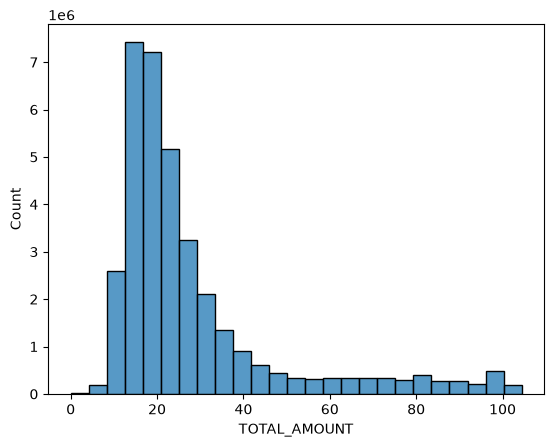

In [48]:
sns.histplot(data=filtered_total_df, x='TOTAL_AMOUNT', bins=25)

From the above histogram, we can see that most total amounts are between 10 and 35 dollars. 

### Key findings

- The median total amount is \$21
- The average total amount is \$29.06
- The highest total amount is over \$300,000
- Outliers do not have justifiable reasons for high costs. Most have
    - Small distances
    - Short durations
    - Some outliers are justified by high tips, but only a minority. 
- The 99th percentile is around \$104.41
- Majority of fares are between \$10 and \\$35
- Further investigation required before establishing a total amount cleaning rule

## Next Session

1. Investigate Trip Distance